# 🏟️ Análisis de Ineficiencias del Mercado de Apuestas en LaLiga con PySpark

Este notebook analiza **cinco temporadas de LaLiga española** (2020/21 – 2024/25) para detectar ineficiencias entre las cuotas implícitas de Bet365 / Pinnacle y los resultados reales.

| Sección | Contenido |
|---------|-----------|
| 1 | Instalación y configuración |
| 2 | Ingesta y limpieza robusta |
| 3 | Modelado Estrella (Dim_Equipo, Dim_Tiempo, Fact_Partidos) |
| 4 | Construcción del Cubo OLAP |
| 5 | Roll-up, Drill-down, Slice & Dice con visualizaciones |


In [6]:
!pip install pyspark --quiet

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (FloatType, IntegerType, DateType, StringType)
from pyspark.sql.window import Window

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob, os

# ── Estilo visual uniforme (igual que notebook de referencia) ─────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

COLORES = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3',
           '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

spark = (SparkSession.builder
         .appName('LaLiga_Apuestas_OLAP')
         .config('spark.sql.repl.eagerEval.enabled', True)
         .getOrCreate())
spark.sparkContext.setLogLevel('ERROR')

print('✅ PySpark y Matplotlib listos')
print(f'   Spark: {spark.version}')


✅ PySpark y Matplotlib listos
   Spark: 4.0.2


## ⚙️ Paso 1: Ingesta y Limpieza Robusta

Se cargan los 5 archivos `SP1 (3).csv … SP1 (7).csv` (temporadas 2020/21 – 2024/25) provenientes de **football-data.co.uk**.

Como cada temporada puede tener columnas distintas (Bet Exchange, 1XBet…), se usa `unionByName(allowMissingColumns=True)` para consolidar sin pérdida de datos.

**Transformaciones aplicadas:**
- `Date` → `DateType` (formato `dd/MM/yyyy`)
- `B365H/D/A`, `PSH/D/A` → `FloatType`
- `FTHG`, `FTAG` → `IntegerType`
- `Temporada` derivada de la fecha (agosto–diciembre → AÑO/AÑO+1)
- Probabilidades implícitas: `Prob_H = 1/B365H`, `Prob_D = 1/B365D`, `Prob_A = 1/B365A`
- `Margen_B365` = suma de probabilidades implícitas (overround del corredor de apuestas)


In [7]:
# ── Localizar archivos CSV en Colab ──────────────────────────────────────────
csv_files = sorted(glob.glob('/content/SP1*.csv'))

if not csv_files:
    print("⚠️  Archivos no encontrados en /content/. Subiendo manualmente…")
    from google.colab import files
    files.upload()
    csv_files = sorted(glob.glob('/content/SP1*.csv'))

print(f"📂 Archivos encontrados: {len(csv_files)}")
for f in csv_files:
    print(f"   ✓ {os.path.basename(f)}")

# ── Carga individual y unión ───────────────────────────────────────────────────
dfs = [spark.read.csv(f, header=True, inferSchema=False) for f in csv_files]

df_raw = dfs[0]
for d in dfs[1:]:
    df_raw = df_raw.unionByName(d, allowMissingColumns=True)

print(f"\n✅ DataFrame unificado: {df_raw.count()} registros | {len(df_raw.columns)} columnas")


📂 Archivos encontrados: 5
   ✓ SP1 (3).csv
   ✓ SP1 (4).csv
   ✓ SP1 (5).csv
   ✓ SP1 (6).csv
   ✓ SP1 (7).csv

✅ DataFrame unificado: 1900 registros | 131 columnas


In [8]:
# ── Casteo de tipos ────────────────────────────────────────────────────────────
df_cast = (df_raw
    .withColumn("Date",  F.to_date(F.col("Date"), "dd/MM/yyyy"))
    .withColumn("B365H", F.col("B365H").cast(FloatType()))
    .withColumn("B365D", F.col("B365D").cast(FloatType()))
    .withColumn("B365A", F.col("B365A").cast(FloatType()))
    .withColumn("PSH",   F.col("PSH").cast(FloatType()))
    .withColumn("PSD",   F.col("PSD").cast(FloatType()))
    .withColumn("PSA",   F.col("PSA").cast(FloatType()))
    .withColumn("FTHG",  F.col("FTHG").cast(IntegerType()))
    .withColumn("FTAG",  F.col("FTAG").cast(IntegerType()))
    .withColumn("Anio",  F.year(F.col("Date")))
    .withColumn("Mes",   F.month(F.col("Date")))
    .filter(F.col("Date").isNotNull() & F.col("FTR").isNotNull() & F.col("B365H").isNotNull())
)

# ── Lógica de negocio: Temporada ──────────────────────────────────────────────
# Agosto–diciembre → AÑO/AÑO+1  |  Enero–julio → (AÑO-1)/AÑO
df_clean = df_cast.withColumn(
    "Temporada",
    F.when(
        F.col("Mes") >= 8,
        F.concat(F.col("Anio").cast(StringType()), F.lit("/"),
                 (F.col("Anio") + 1).cast(StringType()))
    ).otherwise(
        F.concat((F.col("Anio") - 1).cast(StringType()), F.lit("/"),
                 F.col("Anio").cast(StringType()))
    )
)

# ── Probabilidades implícitas y margen del corredor ───────────────────────────
df_clean = (df_clean
    .withColumn("Prob_H",      F.round(F.lit(1.0) / F.col("B365H"), 4))
    .withColumn("Prob_D",      F.round(F.lit(1.0) / F.col("B365D"), 4))
    .withColumn("Prob_A",      F.round(F.lit(1.0) / F.col("B365A"), 4))
    .withColumn("Margen_B365", F.round(
        F.lit(1.0)/F.col("B365H") + F.lit(1.0)/F.col("B365D") + F.lit(1.0)/F.col("B365A"), 4
    ))
)

print(f"✅ DataFrame limpio: {df_clean.count()} partidos")
df_clean.select(
    "Date","Temporada","HomeTeam","AwayTeam","FTR",
    "B365H","B365D","B365A","Prob_H","Prob_D","Prob_A","Margen_B365"
).show(5, truncate=20)


✅ DataFrame limpio: 1900 partidos
+----------+---------+----------+----------+---+-----+-----+-----+------+------+------+-----------+
|      Date|Temporada|  HomeTeam|  AwayTeam|FTR|B365H|B365D|B365A|Prob_H|Prob_D|Prob_A|Margen_B365|
+----------+---------+----------+----------+---+-----+-----+-----+------+------+------+-----------+
|2020-09-12|2020/2021|     Eibar|     Celta|  D|  2.5| 3.25|  2.9|   0.4|0.3077|0.3448|     1.0525|
|2020-09-12|2020/2021|   Granada|Ath Bilbao|  H| 2.75|  3.1| 2.75|0.3636|0.3226|0.3636|     1.0499|
|2020-09-12|2020/2021|     Cadiz|   Osasuna|  A|  2.8|  3.0| 2.75|0.3571|0.3333|0.3636|     1.0541|
|2020-09-13|2020/2021|    Alaves|     Betis|  A|  2.8|  3.2|  2.6|0.3571|0.3125|0.3846|     1.0543|
|2020-09-13|2020/2021|Valladolid|  Sociedad|  D|  2.8|  3.2|  2.6|0.3571|0.3125|0.3846|     1.0543|
+----------+---------+----------+----------+---+-----+-----+-----+------+------+------+-----------+
only showing top 5 rows


## 🏗️ Paso 2: Modelado Estrella (Normalización)

Se divide el DataFrame central en tres entidades que forman un **esquema en estrella**:

```
Dim_Equipo ──┐
             ├──► Fact_Partidos ◄──── Dim_Tiempo
Dim_Equipo ──┘
```

| Tabla | Descripción |
|-------|-------------|
| `Dim_Equipo` | Catálogo único de equipos (extraído de HomeTeam + AwayTeam) |
| `Dim_Tiempo` | Atributos de Fecha, Mes, Año, Trimestre y Temporada |
| `Fact_Partidos` | Hechos: resultados, goles y todas las cuotas disponibles |


In [9]:
# ── Dim_Equipo: catálogo único de equipos ─────────────────────────────────────
equipos_local = df_clean.select(F.col("HomeTeam").alias("Equipo"))
equipos_visit = df_clean.select(F.col("AwayTeam").alias("Equipo"))

Dim_Equipo = (equipos_local.union(equipos_visit)
    .distinct()
    .orderBy("Equipo")
    .withColumn("ID_Equipo", F.monotonically_increasing_id())
    .select("ID_Equipo", "Equipo")
)
Dim_Equipo.createOrReplaceTempView("Dim_Equipo")
print(f"✅ Dim_Equipo: {Dim_Equipo.count()} equipos únicos")
Dim_Equipo.show(truncate=False)


✅ Dim_Equipo: 27 equipos únicos
+---------+----------+
|ID_Equipo|Equipo    |
+---------+----------+
|0        |Alaves    |
|1        |Almeria   |
|2        |Ath Bilbao|
|3        |Ath Madrid|
|4        |Barcelona |
|5        |Betis     |
|6        |Cadiz     |
|7        |Celta     |
|8        |Eibar     |
|9        |Elche     |
|10       |Espanol   |
|11       |Getafe    |
|12       |Girona    |
|13       |Granada   |
|14       |Huesca    |
|15       |Las Palmas|
|16       |Leganes   |
|17       |Levante   |
|18       |Mallorca  |
|19       |Osasuna   |
+---------+----------+
only showing top 20 rows


In [10]:
# ── Dim_Tiempo: atributos temporales por fecha única ─────────────────────────
Dim_Tiempo = (df_clean
    .select(
        F.col("Date").alias("Fecha"),
        F.col("Mes"),
        F.col("Anio"),
        F.col("Temporada"),
        F.quarter(F.col("Date")).alias("Trimestre"),
    )
    .distinct()
    .orderBy("Fecha")
)
Dim_Tiempo.createOrReplaceTempView("Dim_Tiempo")
print(f"✅ Dim_Tiempo: {Dim_Tiempo.count()} fechas únicas")
Dim_Tiempo.show(5)


✅ Dim_Tiempo: 696 fechas únicas
+----------+---+----+---------+---------+
|     Fecha|Mes|Anio|Temporada|Trimestre|
+----------+---+----+---------+---------+
|2020-09-12|  9|2020|2020/2021|        3|
|2020-09-13|  9|2020|2020/2021|        3|
|2020-09-19|  9|2020|2020/2021|        3|
|2020-09-20|  9|2020|2020/2021|        3|
|2020-09-26|  9|2020|2020/2021|        3|
+----------+---+----+---------+---------+
only showing top 5 rows


In [11]:
# ── Fact_Partidos: tabla de hechos central ────────────────────────────────────
Fact_Partidos = df_clean.select(
    F.monotonically_increasing_id().alias("ID_Partido"),
    F.col("Date").alias("Fecha"),
    "HomeTeam", "AwayTeam",
    "FTHG", "FTAG", "FTR",
    "B365H", "B365D", "B365A",
    "PSH",   "PSD",   "PSA",
    "Prob_H", "Prob_D", "Prob_A",
    "Margen_B365",
    "Temporada", "Mes", "Anio",
)
Fact_Partidos.createOrReplaceTempView("Fact_Partidos")

print(f"✅ Fact_Partidos: {Fact_Partidos.count()} partidos")
print(f"   Columnas: {Fact_Partidos.columns}")
Fact_Partidos.show(3, truncate=18)


✅ Fact_Partidos: 1900 partidos
   Columnas: ['ID_Partido', 'Fecha', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'B365H', 'B365D', 'B365A', 'PSH', 'PSD', 'PSA', 'Prob_H', 'Prob_D', 'Prob_A', 'Margen_B365', 'Temporada', 'Mes', 'Anio']
+----------+----------+--------+----------+----+----+---+-----+-----+-----+----+----+----+------+------+------+-----------+---------+---+----+
|ID_Partido|     Fecha|HomeTeam|  AwayTeam|FTHG|FTAG|FTR|B365H|B365D|B365A| PSH| PSD| PSA|Prob_H|Prob_D|Prob_A|Margen_B365|Temporada|Mes|Anio|
+----------+----------+--------+----------+----+----+---+-----+-----+-----+----+----+----+------+------+------+-----------+---------+---+----+
|         0|2020-09-12|   Eibar|     Celta|   0|   0|  D|  2.5| 3.25|  2.9| 2.6|3.22|3.01|   0.4|0.3077|0.3448|     1.0525|2020/2021|  9|2020|
|         1|2020-09-12| Granada|Ath Bilbao|   2|   0|  H| 2.75|  3.1| 2.75|2.92|3.02|2.82|0.3636|0.3226|0.3636|     1.0499|2020/2021|  9|2020|
|         2|2020-09-12|   Cadiz|   Osasuna|   0| 

## 🔗 Paso 3: Construcción del Cubo OLAP

Se desnormaliza el esquema en estrella realizando **joins** entre la tabla de hechos y las dimensiones para obtener `Cubo_Apuestas`: un único DataFrame analítico con toda la información de cada partido en una sola fila.

El cubo queda registrado como vista SQL (`createOrReplaceTempView`) para poder ejecutar operaciones OLAP con `spark.sql(...)`.


In [12]:
# ── Alias de Dim_Equipo para local y visitante ────────────────────────────────
dim_local = (Dim_Equipo
    .withColumnRenamed("Equipo",    "HomeTeam")
    .withColumnRenamed("ID_Equipo", "ID_Local"))

dim_visit = (Dim_Equipo
    .withColumnRenamed("Equipo",    "AwayTeam")
    .withColumnRenamed("ID_Equipo", "ID_Visitante"))

# ── Desnormalización: Cubo_Apuestas ───────────────────────────────────────────
Cubo_Apuestas = (Fact_Partidos
    .join(dim_local, on="HomeTeam", how="left")
    .join(dim_visit, on="AwayTeam", how="left")
)
Cubo_Apuestas.createOrReplaceTempView("Cubo_Apuestas")

print(f"✅ Cubo_Apuestas: {Cubo_Apuestas.count()} filas × {len(Cubo_Apuestas.columns)} columnas")
Cubo_Apuestas.select(
    "Fecha","Temporada","HomeTeam","AwayTeam","FTR",
    "Prob_H","Prob_D","Prob_A","Margen_B365"
).show(5, truncate=18)


✅ Cubo_Apuestas: 1900 filas × 22 columnas
+----------+---------+----------+----------+---+------+------+------+-----------+
|     Fecha|Temporada|  HomeTeam|  AwayTeam|FTR|Prob_H|Prob_D|Prob_A|Margen_B365|
+----------+---------+----------+----------+---+------+------+------+-----------+
|2020-09-12|2020/2021|     Eibar|     Celta|  D|   0.4|0.3077|0.3448|     1.0525|
|2020-09-12|2020/2021|   Granada|Ath Bilbao|  H|0.3636|0.3226|0.3636|     1.0499|
|2020-09-12|2020/2021|     Cadiz|   Osasuna|  A|0.3571|0.3333|0.3636|     1.0541|
|2020-09-13|2020/2021|    Alaves|     Betis|  A|0.3571|0.3125|0.3846|     1.0543|
|2020-09-13|2020/2021|Valladolid|  Sociedad|  D|0.3571|0.3125|0.3846|     1.0543|
+----------+---------+----------+----------+---+------+------+------+-----------+
only showing top 5 rows


## 📊 Paso 4: Análisis Analítico (Operaciones OLAP)

Se ejecutan cuatro operaciones OLAP sobre el cubo:

| Operación | Descripción | Gráfico |
|-----------|-------------|---------|
| **Roll-up** | Promedio de cuotas por Temporada × Mes | Líneas |
| **Drill-down** | Margen de Error por equipo (Prob implícita vs resultado real) | Barras horizontales |
| **Slice** | Partidos con discrepancia B365 vs Pinnacle > 10% | Histograma |
| **Dice** | Comparativa B365 vs Pinnacle por Temporada | Barras agrupadas |


### 🔺 Roll-up: Evolución de Cuotas Promedio por Temporada y Mes

**Roll-up** = agregación ascendente en la jerarquía temporal (partido → mes → temporada).

Se calcula el **promedio mensual** de cuotas de victoria local, empate y victoria visitante. El gráfico de líneas es ideal para esta operación porque muestra la **tendencia y evolución** a lo largo del tiempo, permitiendo comparar temporadas de un vistazo.


+---------+---+---------+----------+-------------+------------+
|Temporada|Mes|Avg_Local|Avg_Empate|Avg_Visitante|Num_Partidos|
+---------+---+---------+----------+-------------+------------+
|2020/2021|  1|   3.1306|    3.6965|       3.7106|          49|
|2020/2021|  2|   2.7528|     3.807|       4.4295|          43|
|2020/2021|  3|     2.71|    3.8403|       4.3991|          33|
|2020/2021|  4|   2.7363|    3.7849|       4.2561|          51|
|2020/2021|  5|   3.0006|      4.01|         4.05|          49|
|2020/2021|  9|   2.6563|    3.5743|       3.8683|          30|
|2020/2021| 10|   2.8358|    3.6016|       4.0095|          38|
|2020/2021| 11|   2.5414|     3.668|       4.0946|          35|
|2020/2021| 12|   2.8088|      3.84|        4.271|          52|
|2021/2022|  1|   2.6254|    3.7017|        4.474|          35|
|2021/2022|  2|   2.4566|    3.6617|       4.3759|          41|
|2021/2022|  3|   2.6887|    3.5494|       3.8539|          31|
|2021/2022|  4|   2.4611|    3.7561|    

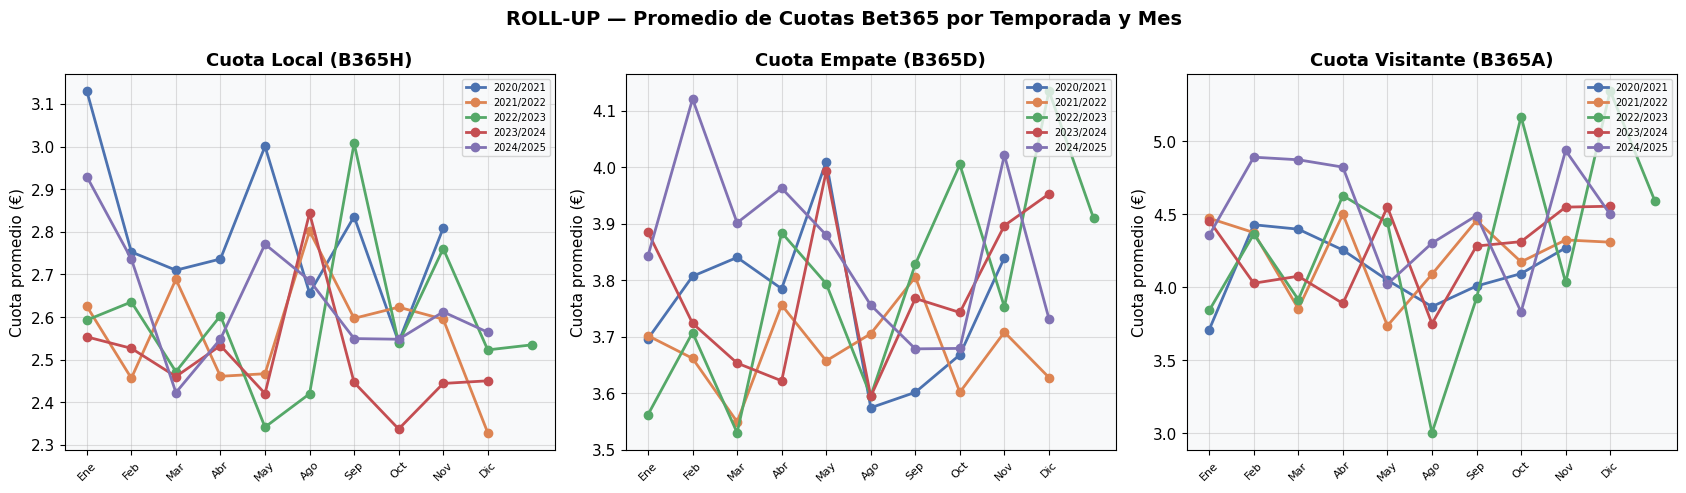

💡 Roll-up: cuotas promedio por mes/temporada. Valores más altos indican mayor incertidumbre percibida por el mercado.


In [13]:
# ── Consulta OLAP: Roll-up ────────────────────────────────────────────────────
rollup_df = spark.sql('''
    SELECT Temporada, Mes,
           ROUND(AVG(B365H), 4) AS Avg_Local,
           ROUND(AVG(B365D), 4) AS Avg_Empate,
           ROUND(AVG(B365A), 4) AS Avg_Visitante,
           COUNT(*)             AS Num_Partidos
    FROM Cubo_Apuestas
    GROUP BY Temporada, Mes
    ORDER BY Temporada, Mes
''')
rollup_df.show(20)

# ── Gráfico de líneas ─────────────────────────────────────────────────────────
df_rollup  = rollup_df.toPandas()
temporadas = sorted(df_rollup["Temporada"].unique())

MESES = {8:"Ago",9:"Sep",10:"Oct",11:"Nov",12:"Dic",
         1:"Ene",2:"Feb",3:"Mar",4:"Abr",5:"May",6:"Jun",7:"Jul"}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("ROLL-UP — Promedio de Cuotas Bet365 por Temporada y Mes",
             fontsize=14, fontweight="bold")

cols_y  = ["Avg_Local", "Avg_Empate", "Avg_Visitante"]
titulos = ["Cuota Local (B365H)", "Cuota Empate (B365D)", "Cuota Visitante (B365A)"]

for ax, col_y, titulo in zip(axes, cols_y, titulos):
    for i, temp in enumerate(temporadas):
        datos = df_rollup[df_rollup["Temporada"] == temp].sort_values("Mes")
        etiq  = [MESES.get(m, str(m)) for m in datos["Mes"]]
        ax.plot(range(len(datos)), datos[col_y], marker="o",
                label=temp, color=COLORES[i % len(COLORES)], linewidth=2)
        ax.set_xticks(range(len(etiq)))
        ax.set_xticklabels(etiq, rotation=45, fontsize=8)
    ax.set_title(titulo)
    ax.set_ylabel("Cuota promedio (€)")
    ax.legend(fontsize=7, loc="upper right")

plt.tight_layout()
plt.show()
print("💡 Roll-up: cuotas promedio por mes/temporada. Valores más altos indican mayor incertidumbre percibida por el mercado.")


### 🔻 Drill-down: Margen de Error por Equipo (Probabilidad Implícita vs Resultado Real)

**Drill-down** = descenso en la jerarquía dimensional: de temporada global → equipo individual.

**Margen de Error** = |Probabilidad Implícita de victoria local (Prob_H) − Tasa real de victorias locales|

Un margen alto indica que el mercado **sobreestimó o subestimó** sistemáticamente las chances de ese equipo. El gráfico de barras horizontales compara equipos de forma directa.


🔻 Top 20 (equipo × temporada) con mayor Margen de Error:
+----------+---------+--------------+--------------+------------------+------------+
|    Equipo|Temporada|Partidos_Local|Prob_Implicita|Tasa_Real_Victoria|Margen_Error|
+----------+---------+--------------+--------------+------------------+------------+
|   Almeria|2023/2024|            19|        0.3227|            0.0526|      0.2701|
|     Eibar|2020/2021|            19|        0.3559|            0.1053|      0.2507|
|    Girona|2023/2024|            19|        0.5585|            0.7895|       0.231|
| Vallecano|2023/2024|            19|        0.4192|            0.2105|      0.2086|
|Valladolid|2020/2021|            19|        0.3528|            0.1579|      0.1949|
|Ath Madrid|2023/2024|            19|        0.6493|            0.8421|      0.1928|
|   Almeria|2022/2023|            19|        0.3442|            0.5263|      0.1821|
| Barcelona|2020/2021|            19|        0.7576|            0.5790|      0.1786|
|    Get

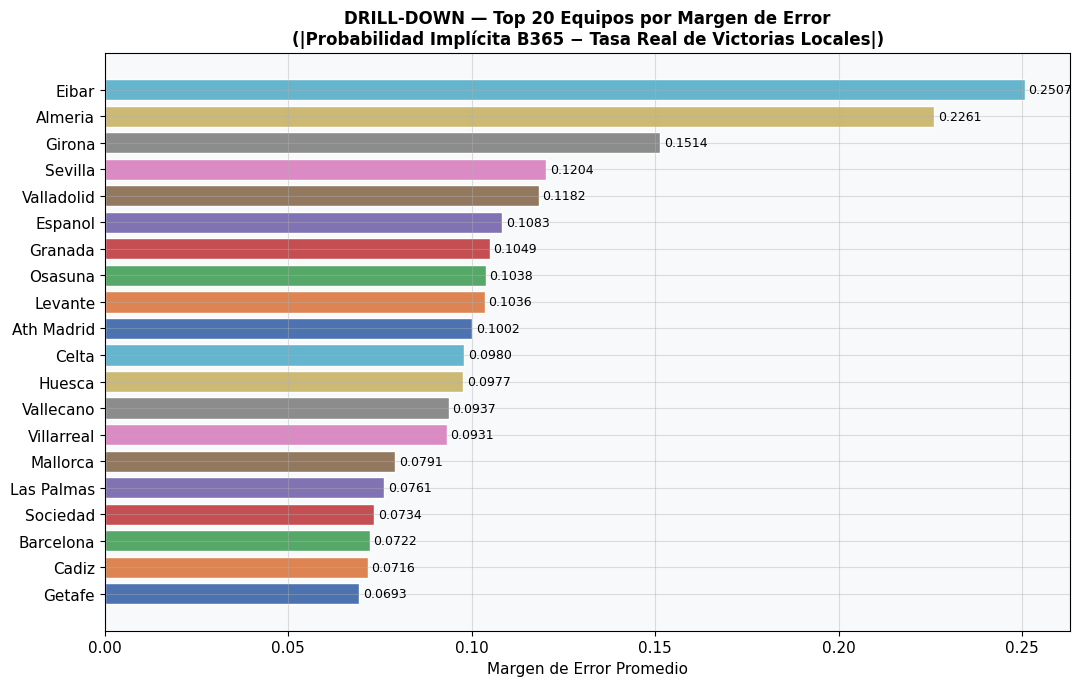

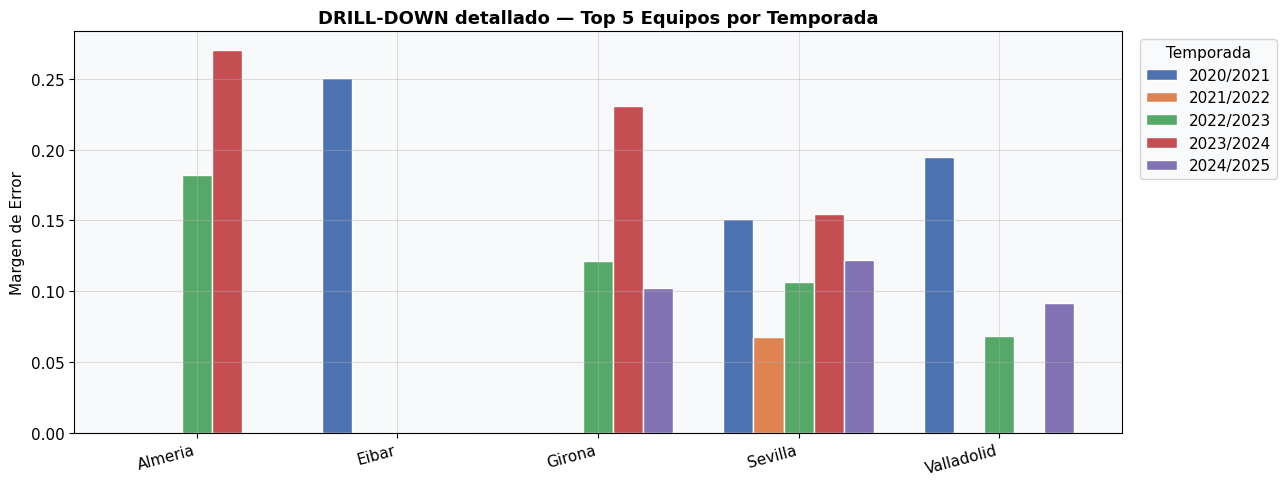

💡 Drill-down: bajamos de la temporada al nivel de equipo. Cuanto mayor el margen, mayor la ineficiencia del mercado para ese club.


In [14]:
# ── Consulta OLAP: Drill-down ─────────────────────────────────────────────────
drill_df = spark.sql('''
    SELECT HomeTeam AS Equipo,
           Temporada,
           COUNT(*)  AS Partidos_Local,
           ROUND(AVG(Prob_H), 4) AS Prob_Implicita,
           ROUND(AVG(CASE WHEN FTR = 'H' THEN 1.0 ELSE 0.0 END), 4) AS Tasa_Real_Victoria,
           ROUND(ABS(
               AVG(Prob_H) - AVG(CASE WHEN FTR = 'H' THEN 1.0 ELSE 0.0 END)
           ), 4) AS Margen_Error
    FROM Cubo_Apuestas
    GROUP BY HomeTeam, Temporada
    HAVING COUNT(*) >= 5
    ORDER BY Margen_Error DESC
''')
print("🔻 Top 20 (equipo × temporada) con mayor Margen de Error:")
drill_df.show(20, truncate=22)

df_drill = drill_df.toPandas()

# ── Gráfico 1: Top 20 equipos por Margen de Error promedio ───────────────────
top20 = (df_drill
    .groupby("Equipo", as_index=False)["Margen_Error"]
    .mean()
    .nlargest(20, "Margen_Error")
    .sort_values("Margen_Error"))

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top20["Equipo"], top20["Margen_Error"],
               color=COLORES[:len(top20)], edgecolor="white")
ax.set_title("DRILL-DOWN — Top 20 Equipos por Margen de Error\n"
             "(|Probabilidad Implícita B365 − Tasa Real de Victorias Locales|)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Margen de Error Promedio")
for bar, val in zip(bars, top20["Margen_Error"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# ── Gráfico 2: Drill-down por temporada (top 5 equipos) ──────────────────────
top5_equipos = top20["Equipo"].tail(5).tolist()
df_top5 = df_drill[df_drill["Equipo"].isin(top5_equipos)]
pivot = df_top5.pivot_table(index="Equipo", columns="Temporada",
                             values="Margen_Error", aggfunc="mean", fill_value=0)

x     = np.arange(len(pivot.index))
ancho = 0.15
fig2, ax2 = plt.subplots(figsize=(13, 5))
for j, temp in enumerate(pivot.columns):
    offset = (j - len(pivot.columns)/2 + 0.5) * ancho
    ax2.bar(x + offset, pivot[temp], ancho, label=temp,
            color=COLORES[j % len(COLORES)], edgecolor="white")
ax2.set_title("DRILL-DOWN detallado — Top 5 Equipos por Temporada",
              fontsize=13, fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(pivot.index, rotation=15, ha="right")
ax2.set_ylabel("Margen de Error")
ax2.legend(title="Temporada", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()
print("💡 Drill-down: bajamos de la temporada al nivel de equipo. Cuanto mayor el margen, mayor la ineficiencia del mercado para ese club.")


### 🔪 Slice & Dice: Bet365 vs Pinnacle — Discrepancias Mayores al 10%

**Slice** = fijar un corte sobre los datos: partidos donde la diferencia entre probabilidades implícitas de **Bet365 y Pinnacle** supera el **10%** en cualquier resultado.

**Dice** = cruzar dos dimensiones simultáneamente: **casa de apuestas × temporada**, comparando cuotas promedio de ambas fuentes en cada año.

Pinnacle es considerada la casa de apuestas más eficiente del mercado. Una discrepancia elevada respecto a Bet365 sugiere que **una de las dos está equivocada** — potencial ineficiencia explotable.


🔪 Partidos con discrepancia > 10%: 0 de 1899 (0.0%)
+-----+--------+--------+---+---------+----------+--------+-----------+---------+----------+--------+----------+-----------+----------+----------+
|Fecha|HomeTeam|AwayTeam|FTR|Temporada|B365_Local|PS_Local|B365_Empate|PS_Empate|B365_Visit|PS_Visit|Disc_Local|Disc_Empate|Disc_Visit|Disc_Total|
+-----+--------+--------+---+---------+----------+--------+-----------+---------+----------+--------+----------+-----------+----------+----------+
+-----+--------+--------+---+---------+----------+--------+-----------+---------+----------+--------+----------+-----------+----------+----------+


🎲 Dice — Comparativa B365 vs Pinnacle por Temporada:
+---------+--------------+------------+---------------+-------------+--------------+------------+--------+
|Temporada|Avg_B365_Local|Avg_PS_Local|Avg_B365_Empate|Avg_PS_Empate|Avg_B365_Visit|Avg_PS_Visit|Partidos|
+---------+--------------+------------+---------------+-------------+--------------+-------

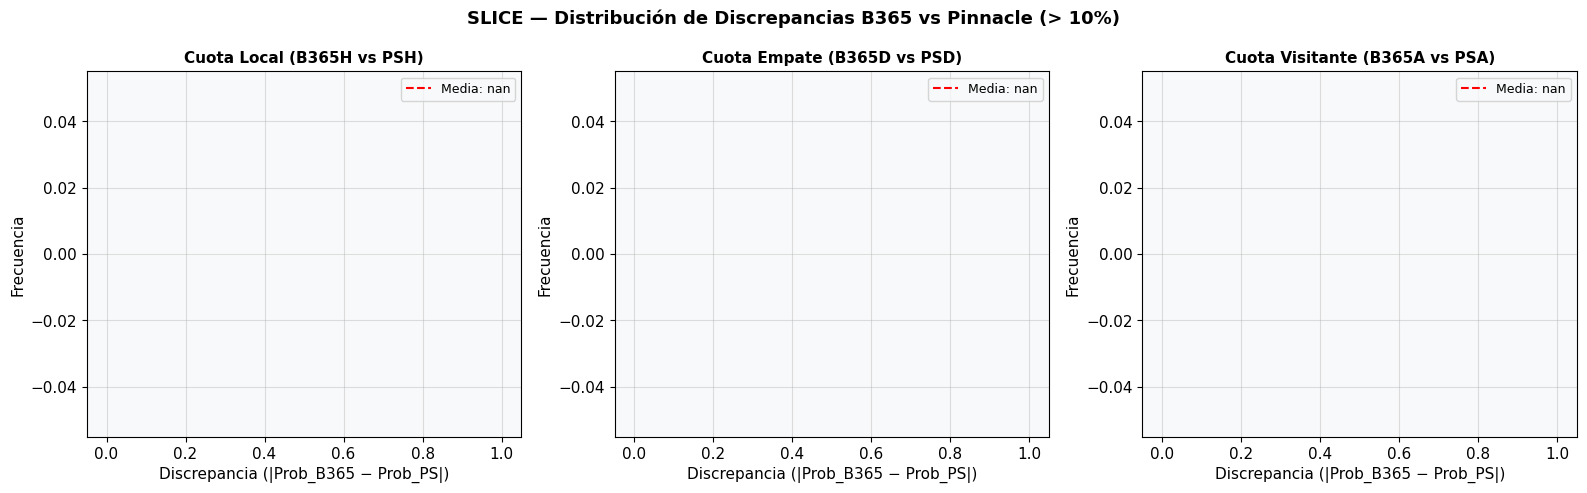

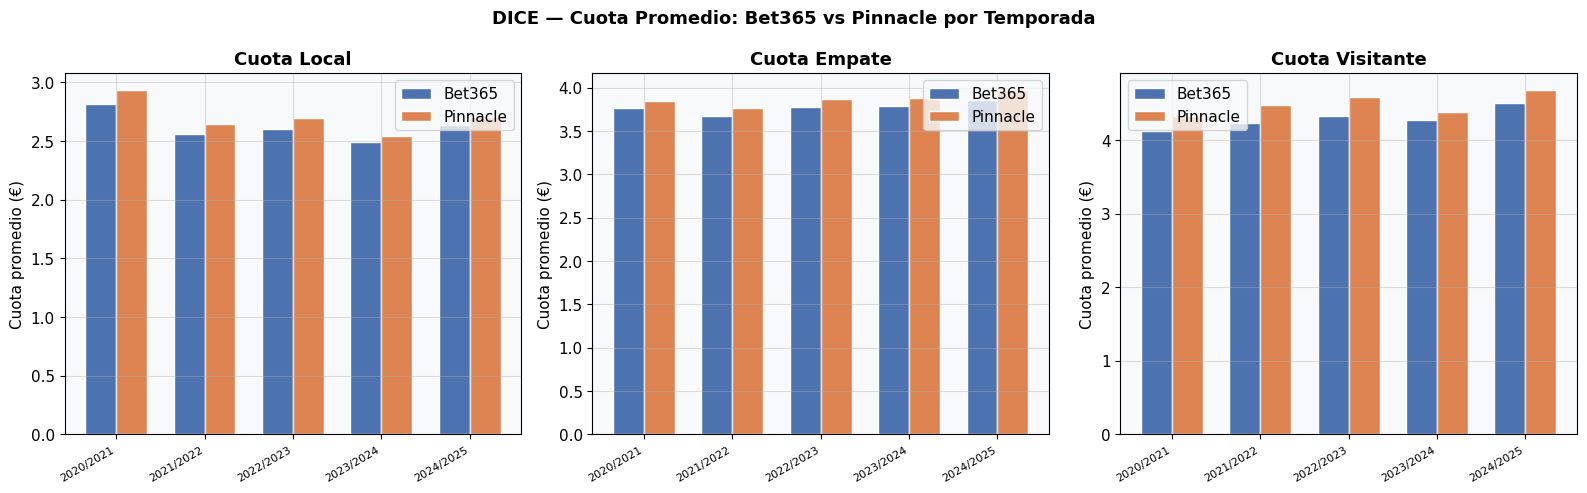

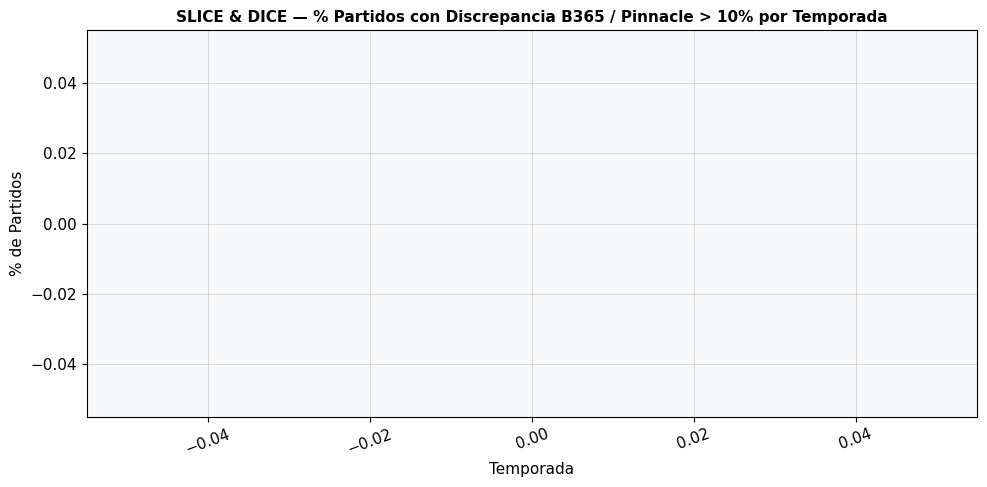

💡 Slice: aislamos oportunidades de valor. Dice: cruzamos casa de apuestas × temporada para detectar si las discrepancias son estructurales.


In [15]:
# ── Slice: partidos con discrepancia B365 vs Pinnacle > 10% ──────────────────
slice_df = spark.sql('''
    SELECT Fecha, HomeTeam, AwayTeam, FTR, Temporada,
           ROUND(B365H, 2)            AS B365_Local,
           ROUND(PSH,   2)            AS PS_Local,
           ROUND(B365D, 2)            AS B365_Empate,
           ROUND(PSD,   2)            AS PS_Empate,
           ROUND(B365A, 2)            AS B365_Visit,
           ROUND(PSA,   2)            AS PS_Visit,
           ROUND(ABS(1/B365H - 1/PSH), 4) AS Disc_Local,
           ROUND(ABS(1/B365D - 1/PSD), 4) AS Disc_Empate,
           ROUND(ABS(1/B365A - 1/PSA), 4) AS Disc_Visit,
           ROUND(ABS(1/B365H - 1/PSH)
               + ABS(1/B365D - 1/PSD)
               + ABS(1/B365A - 1/PSA), 4) AS Disc_Total
    FROM Cubo_Apuestas
    WHERE PSH IS NOT NULL AND PSD IS NOT NULL AND PSA IS NOT NULL
      AND B365H IS NOT NULL AND B365D IS NOT NULL AND B365A IS NOT NULL
      AND (ABS(1/B365H - 1/PSH) > 0.10
        OR ABS(1/B365D - 1/PSD) > 0.10
        OR ABS(1/B365A - 1/PSA) > 0.10)
    ORDER BY Disc_Total DESC
''')

total_disc = slice_df.count()
total_ps   = spark.sql('''
    SELECT COUNT(*) FROM Cubo_Apuestas
    WHERE PSH IS NOT NULL AND B365H IS NOT NULL
''').collect()[0][0]

print(f"🔪 Partidos con discrepancia > 10%: {total_disc} de {total_ps} ({100*total_disc/total_ps:.1f}%)")
slice_df.show(10, truncate=16)

# ── Dice: B365 vs Pinnacle por Temporada ─────────────────────────────────────
dice_df = spark.sql('''
    SELECT Temporada,
           ROUND(AVG(B365H), 4) AS Avg_B365_Local,
           ROUND(AVG(PSH),   4) AS Avg_PS_Local,
           ROUND(AVG(B365D), 4) AS Avg_B365_Empate,
           ROUND(AVG(PSD),   4) AS Avg_PS_Empate,
           ROUND(AVG(B365A), 4) AS Avg_B365_Visit,
           ROUND(AVG(PSA),   4) AS Avg_PS_Visit,
           COUNT(*)             AS Partidos
    FROM Cubo_Apuestas
    WHERE PSH IS NOT NULL AND B365H IS NOT NULL
    GROUP BY Temporada
    ORDER BY Temporada
''')
print("\n🎲 Dice — Comparativa B365 vs Pinnacle por Temporada:")
dice_df.show()

df_slice = slice_df.toPandas()
df_dice  = dice_df.toPandas()

# ── Gráfico 1: Histogramas de discrepancias ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("SLICE — Distribución de Discrepancias B365 vs Pinnacle (> 10%)",
             fontsize=13, fontweight="bold")

disc_cols   = ["Disc_Local", "Disc_Empate", "Disc_Visit"]
disc_labels = ["Cuota Local (B365H vs PSH)", "Cuota Empate (B365D vs PSD)", "Cuota Visitante (B365A vs PSA)"]

for ax, col, label in zip(axes, disc_cols, disc_labels):
    ax.hist(df_slice[col], bins=20, color=COLORES[disc_cols.index(col)],
            edgecolor="white", alpha=0.85)
    media = df_slice[col].mean()
    ax.axvline(media, color="red", linestyle="--", linewidth=1.5,
               label=f"Media: {media:.3f}")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Discrepancia (|Prob_B365 − Prob_PS|)")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Gráfico 2: Barras agrupadas B365 vs Pinnacle por Temporada ────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle("DICE — Cuota Promedio: Bet365 vs Pinnacle por Temporada",
              fontsize=13, fontweight="bold")

pares = [("Avg_B365_Local",  "Avg_PS_Local",  "Cuota Local"),
         ("Avg_B365_Empate", "Avg_PS_Empate", "Cuota Empate"),
         ("Avg_B365_Visit",  "Avg_PS_Visit",  "Cuota Visitante")]

x     = np.arange(len(df_dice))
ancho = 0.35
for ax, (col_b, col_p, titulo) in zip(axes2, pares):
    b1 = ax.bar(x - ancho/2, df_dice[col_b], ancho,
                label="Bet365",   color=COLORES[0], edgecolor="white")
    b2 = ax.bar(x + ancho/2, df_dice[col_p], ancho,
                label="Pinnacle", color=COLORES[1], edgecolor="white")
    ax.set_title(titulo)
    ax.set_xticks(x)
    ax.set_xticklabels(df_dice["Temporada"], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Cuota promedio (€)")
    ax.legend()

plt.tight_layout()
plt.show()

# ── Gráfico 3: % de partidos discrepantes por Temporada ──────────────────────
disc_temp   = (df_slice.groupby("Temporada").size()
               .reset_index(name="Num_Disc"))
total_temp  = (spark.sql('''
    SELECT Temporada, COUNT(*) AS Total
    FROM Cubo_Apuestas WHERE PSH IS NOT NULL AND B365H IS NOT NULL
    GROUP BY Temporada ORDER BY Temporada
''').toPandas())
merged = disc_temp.merge(total_temp, on="Temporada")
merged["Pct"] = 100 * merged["Num_Disc"] / merged["Total"]

fig3, ax3 = plt.subplots(figsize=(10, 5))
bars3 = ax3.bar(merged["Temporada"], merged["Pct"],
                color=COLORES[:len(merged)], edgecolor="white")
ax3.set_title("SLICE & DICE — % Partidos con Discrepancia B365 / Pinnacle > 10% por Temporada",
              fontsize=11, fontweight="bold")
ax3.set_xlabel("Temporada")
ax3.set_ylabel("% de Partidos")
ax3.tick_params(axis="x", rotation=20)
for bar, val in zip(bars3, merged["Pct"]):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()
print("💡 Slice: aislamos oportunidades de valor. Dice: cruzamos casa de apuestas × temporada para detectar si las discrepancias son estructurales.")


In [16]:
# ── Resumen Final ──────────────────────────────────────────────────────────────
print("=" * 65)
print("📊  RESUMEN DEL ANÁLISIS DE INEFICIENCIAS EN LALIGA (PySpark)")
print("=" * 65)

total_partidos  = Cubo_Apuestas.count()
total_temp      = Cubo_Apuestas.select("Temporada").distinct().count()
total_equipos   = Dim_Equipo.count()
margen_avg      = Cubo_Apuestas.agg(F.round(F.avg("Margen_B365"), 4)).collect()[0][0]
overround_pct   = round((margen_avg - 1) * 100, 2)

print(f"\n📅 Temporadas analizadas : {total_temp}")
print(f"⚽ Total partidos         : {total_partidos}")
print(f"🏟️  Equipos únicos         : {total_equipos}")
print(f"💰 Margen promedio B365   : {margen_avg}  (+{overround_pct}% overround)")
print(f"\n📐 Dimensiones (Modelo Estrella):")
print(f"   Dim_Equipo    → {Dim_Equipo.count()} registros")
print(f"   Dim_Tiempo    → {Dim_Tiempo.count()} registros")
print(f"   Fact_Partidos → {Fact_Partidos.count()} registros")
print(f"\n🎯 Operaciones OLAP ejecutadas:")
print("   ✅ Roll-up    : cuotas promedio por Temporada × Mes")
print("   ✅ Drill-down : Margen de Error por Equipo")
print("   ✅ Slice      : partidos con discrepancia B365/Pinnacle > 10%")
print("   ✅ Dice       : comparativa B365 vs Pinnacle por Temporada")

spark.stop()
print("\n🔴 SparkSession cerrada.")


📊  RESUMEN DEL ANÁLISIS DE INEFICIENCIAS EN LALIGA (PySpark)

📅 Temporadas analizadas : 5
⚽ Total partidos         : 1900
🏟️  Equipos únicos         : 27
💰 Margen promedio B365   : 1.0552  (+5.52% overround)

📐 Dimensiones (Modelo Estrella):
   Dim_Equipo    → 27 registros
   Dim_Tiempo    → 696 registros
   Fact_Partidos → 1900 registros

🎯 Operaciones OLAP ejecutadas:
   ✅ Roll-up    : cuotas promedio por Temporada × Mes
   ✅ Drill-down : Margen de Error por Equipo
   ✅ Slice      : partidos con discrepancia B365/Pinnacle > 10%
   ✅ Dice       : comparativa B365 vs Pinnacle por Temporada

🔴 SparkSession cerrada.
